# Лабораторна робота №3. Використання еволюційних алгоритмів

**Варіант 1.** Генетичний алгоритм для підбору гіперпараметрів нейронної мережі.

**Предметна область:** аналіз задоволеності клієнтів у сфері авіаперевезень.
**Набір даних:** Airline Passenger Satisfaction (Kaggle).
**Модель:** багатошарова нейронна мережа (TensorFlow / Keras), бінарна класифікація.
**Фітнес-функція:** F1-міра класу satisfied на валідаційній вибірці.

Виконав: Колодійчук Олександр, ст. гр. КНСШ-13

## 1. Імпорти та завантаження даних

In [1]:
# Модуль os потрібен, щоб задати змінну середовища до імпорту TensorFlow
import os
# Вимикаємо службові повідомлення TensorFlow (рівень 3 - показувати лише помилки)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# Модуль time - для вимірювання часу навчання та роботи алгоритму
import time
# Модуль random - генератор випадкових чисел для генетичного алгоритму
import random

# NumPy - робота з масивами та математичні операції
import numpy as np
# pandas - робота з табличними даними (DataFrame)
import pandas as pd
# matplotlib - побудова графіків
import matplotlib.pyplot as plt
# seaborn - статистичні графіки (boxplot, теплові карти)
import seaborn as sns

# TensorFlow - фреймворк для побудови та навчання нейронних мереж
import tensorflow as tf
# Модулі Keras: шари (layers), моделі (models) та регуляризатори (regularizers)
from tensorflow.keras import layers, models, regularizers

# Функція для поділу даних на навчальну, валідаційну та тестову вибірки
from sklearn.model_selection import train_test_split
# Стандартизація ознак (mean = 0, std = 1)
from sklearn.preprocessing import StandardScaler
# Метрики якості класифікації
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)

# SMOTE - метод балансування класів генерацією синтетичних записів
from imblearn.over_sampling import SMOTE

# Фіксоване зерно генераторів випадкових чисел, щоб результати були відтворюваними
SEED = 42
# Фіксуємо зерно одночасно для Python, NumPy і TensorFlow
tf.keras.utils.set_random_seed(SEED)
# Приховуємо технічні попередження TensorFlow (про повторну компіляцію графа тощо)
tf.get_logger().setLevel("ERROR")

# Встановлюємо єдиний стиль графіків із сіткою
sns.set_theme(style="whitegrid")

# Завантажуємо набір даних із CSV-файлу в таблицю DataFrame
df = pd.read_csv("AirlinePassengerSatisfaction.csv")

# Виводимо версію TensorFlow
print("Версія TensorFlow:", tf.__version__)
# Виводимо розмір таблиці (рядки, колонки)
print("Розмір набору даних:", df.shape)
# Виводимо кількість записів кожного класу цільової змінної
print("Розподіл цільової змінної:")
print(df["satisfaction"].value_counts())
# Показуємо перші 5 рядків таблиці
df.head()

Версія TensorFlow: 2.20.0
Розмір набору даних: (103904, 25)
Розподіл цільової змінної:
satisfaction
neutral or dissatisfied    58879
satisfied                  45025
Name: count, dtype: int64


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


## 2. Попередня обробка даних

Обробка така сама, як у лабораторних роботах №1–2: видалення службових колонок, заповнення пропусків,
кодування категоріальних ознак і логарифмування асиметричних ознак.

In [2]:
# Створюємо робочу копію датасету, щоб не змінювати оригінальний df
data = df.copy()

# Видаляємо службові колонки: 'Unnamed: 0' - старий індекс, 'id' - номер пасажира;
# вони не несуть корисної інформації для навчання моделі
data = data.drop(columns=["Unnamed: 0", "id"])

# Рахуємо кількість пропущених значень у колонці затримки прибуття
n_missing = data["Arrival Delay in Minutes"].isna().sum()
# Заповнюємо пропуски значенням затримки вильоту того ж рейсу:
# за кореляційним аналізом (лаба 1) ці ознаки майже тотожні (r = 0.965)
data["Arrival Delay in Minutes"] = data["Arrival Delay in Minutes"].fillna(
    data["Departure Delay in Minutes"])

# Словник відповідностей для бінарних категоріальних ознак (дві категорії -> 0/1)
binary_map = {
    # Стать пасажира: чоловік = 0, жінка = 1
    "Gender":         {"Male": 0, "Female": 1},
    # Тип клієнта: нелояльний = 0, лояльний = 1
    "Customer Type":  {"disloyal Customer": 0, "Loyal Customer": 1},
    # Мета подорожі: особиста = 0, ділова = 1
    "Type of Travel": {"Personal Travel": 0, "Business travel": 1},
}
# Проходимо по кожній бінарній ознаці та її словнику відповідностей
for col, mapping in binary_map.items():
    # Замінюємо текстові значення на числові згідно зі словником
    data[col] = data[col].map(mapping)

# Class має 3 категорії (Eco, Eco Plus, Business), тому кодуємо через one-hot:
# створюються 3 окремі колонки 0/1 без штучного порядку між класами
data = pd.get_dummies(data, columns=["Class"], prefix="Class", dtype=int)

# Кодуємо цільову змінну: satisfied = 1, neutral or dissatisfied = 0
data["satisfaction"] = (data["satisfaction"] == "satisfied").astype(int)

# Список ознак із сильною правосторонньою асиметрією (виявлено в EDA лаби 1)
skewed = ["Flight Distance", "Departure Delay in Minutes", "Arrival Delay in Minutes"]
# Застосовуємо log(1 + x): стискає довгий правий хвіст і коректно працює з нулями
data[skewed] = np.log1p(data[skewed])

# Матриця ознак X: усі колонки, крім цільової змінної
X = data.drop(columns=["satisfaction"])
# Вектор міток y: значення цільової змінної у вигляді масиву NumPy
y = data["satisfaction"].values

# Виводимо, скільки пропусків заповнено і скільки залишилось
print(f"Заповнено пропусків: {n_missing}, залишилось: {data.isna().sum().sum()}")
# Виводимо розмірності X та y
print("Розмір X:", X.shape, " розмір y:", y.shape)
# Виводимо кількість ознак, які подаватимуться на вхід мережі
print("Кількість ознак:", X.shape[1])

Заповнено пропусків: 310, залишилось: 0
Розмір X: (103904, 24)  розмір y: (103904,)
Кількість ознак: 24


## 3. Поділ на train / validation / test, масштабування і SMOTE

Поділ 70 / 15 / 15 зі стратифікацією, як у лабах 1–2. Scaler і SMOTE застосовуються лише до train.
Validation використовується для обчислення фітнес-функції, а test – тільки для фінальної перевірки.

In [3]:
# Крок 1: відокремлюємо тестову вибірку (15% усіх даних);
# stratify=y зберігає однакову пропорцію класів в обох частинах
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y)
# Крок 2: з решти 85% відокремлюємо валідаційну вибірку;
# частка 0.15 / 0.85 від залишку дає рівно 15% від усіх даних
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15 / 0.85, random_state=SEED, stratify=y_temp)

# Створюємо об'єкт стандартизації: кожна ознака приводиться до mean = 0 і std = 1
scaler = StandardScaler()
# Навчаємо scaler ТІЛЬКИ на train і одразу трансформуємо train
X_train_sc = scaler.fit_transform(X_train)
# Val і test трансформуємо з параметрами train, щоб уникнути витоку даних
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

# Створюємо об'єкт SMOTE з фіксованим зерном
smote = SMOTE(random_state=SEED)
# Балансуємо ТІЛЬКИ навчальну вибірку; val і test лишаються з реальним розподілом класів
X_train_bal, y_train_bal = smote.fit_resample(X_train_sc, y_train)

# Кількість вхідних ознак мережі (кількість колонок навчальної вибірки)
INPUT_DIM = X_train_bal.shape[1]

# Для кожної вибірки виводимо кількість записів і частку класу satisfied
for name, ys in [("Train (до SMOTE)", y_train), ("Train (після SMOTE)", y_train_bal),
                 ("Validation", y_val), ("Test", y_test)]:
    print(f"{name:<20}: {len(ys):>6} записів, частка satisfied: {ys.mean() * 100:.2f}%")

Train (до SMOTE)    :  72732 записів, частка satisfied: 43.33%
Train (після SMOTE) :  82430 записів, частка satisfied: 50.00%
Validation          :  15586 записів, частка satisfied: 43.33%
Test                :  15586 записів, частка satisfied: 43.33%


## 4. Простір пошуку гіперпараметрів (кодування хромосоми)

Одна особина (хромосома) – це одна конфігурація нейронної мережі, кожен ген – окремий гіперпараметр.
Використано **змішане представлення**:
- дискретні гени – кількість шарів, кількість нейронів, функція активації, Batch Normalization, розмір батча;
- дійсні гени – частка Dropout, а також learning rate і коефіцієнт L2 у логарифмічній шкалі (log10).

In [4]:
# Дискретні гени: для кожного гена задаємо список допустимих значень
DISCRETE_GENES = {
    # Кількість прихованих шарів мережі
    "n_layers":   [1, 2, 3, 4],
    # Кількість нейронів у першому прихованому шарі (кожен наступний шар удвічі менший)
    "units":      [32, 64, 128, 256, 512],
    # Функція активації прихованих шарів (ті самі, що порівнювали в лабах 1-2)
    "activation": ["relu", "leaky_relu", "gelu"],
    # Чи додавати Batch Normalization після кожного Dense-шару
    "batch_norm": [False, True],
    # Розмір батча під час навчання
    "batch_size": [64, 128, 256, 512],
}

# Дійсні гени: для кожного гена задаємо межі (мінімум, максимум)
CONTINUOUS_GENES = {
    # Частка нейронів, які Dropout випадково вимикає (від 0 до 50%)
    "dropout": (0.0, 0.5),
    # Десятковий логарифм learning rate: від -4 (0.0001) до -2 (0.01);
    # логарифмічна шкала дає рівні шанси малим і великим значенням
    "log_lr":  (-4.0, -2.0),
    # Десятковий логарифм коефіцієнта L2: від -6 (0.000001) до -2 (0.01)
    "log_l2":  (-6.0, -2.0),
}

# Повний список назв генів у фіксованому порядку (порядок генів у хромосомі)
GENE_NAMES = list(DISCRETE_GENES) + list(CONTINUOUS_GENES)

# Кількість можливих комбінацій лише дискретних генів (добуток кількостей значень)
n_discrete = int(np.prod([len(v) for v in DISCRETE_GENES.values()]))


# Функція створює випадкову особину: кожен ген отримує випадкове допустиме значення
def random_individual(rng):
    # Для кожного дискретного гена обираємо випадкове значення зі списку
    ind = {g: rng.choice(values) for g, values in DISCRETE_GENES.items()}
    # Для кожного дійсного гена беремо випадкове число з рівномірного розподілу в його межах
    for g, (low, high) in CONTINUOUS_GENES.items():
        # Округлюємо до 3 знаків, щоб однакові особини мали однаковий запис
        ind[g] = round(rng.uniform(low, high), 3)
    # Повертаємо особину у вигляді словника {назва гена: значення}
    return ind


# Функція обчислює розміри прихованих шарів за генами особини
def layer_sizes(ind):
    # Перший шар має units нейронів, кожен наступний удвічі менший, але не менше 16
    return [max(ind["units"] // 2 ** i, 16) for i in range(ind["n_layers"])]


# Функція формує короткий текстовий опис особини одним рядком (для логів і таблиць)
def describe(ind):
    return (f"шари {layer_sizes(ind)}, {ind['activation']}, "
            f"BN={'так' if ind['batch_norm'] else 'ні'}, dropout={ind['dropout']:.2f}, "
            f"lr={10 ** ind['log_lr']:.1e}, L2={10 ** ind['log_l2']:.1e}, batch={ind['batch_size']}")


# Виводимо кількість генів у хромосомі
print("Кількість генів у хромосомі:", len(GENE_NAMES))
# Виводимо назви дискретних і дійсних генів
print("Дискретні гени:", list(DISCRETE_GENES))
print("Дійсні гени:", list(CONTINUOUS_GENES))
# Виводимо розмір простору пошуку
print(f"Лише дискретна частина дає {n_discrete} комбінацій, "
      f"дійсні гени роблять простір пошуку нескінченним")

# Окремий генератор для демонстрації, щоб не впливати на генетичний алгоритм
demo_rng = random.Random(0)
# Виводимо три приклади випадкових особин
print("\nПриклади випадкових особин:")
for i in range(3):
    print(f"  Особина {i + 1}: {describe(random_individual(demo_rng))}")

Кількість генів у хромосомі: 8
Дискретні гени: ['n_layers', 'units', 'activation', 'batch_norm', 'batch_size']
Дійсні гени: ['dropout', 'log_lr', 'log_l2']
Лише дискретна частина дає 480 комбінацій, дійсні гени роблять простір пошуку нескінченним

Приклади випадкових особин:
  Особина 1: шари [256, 128, 64, 32], relu, BN=так, dropout=0.20, lr=3.7e-03, L2=1.6e-05, batch=512
  Особина 2: шари [128, 64, 32, 16], gelu, BN=ні, dropout=0.14, lr=3.3e-03, L2=3.0e-04, batch=128
  Особина 3: шари [512, 256, 128], gelu, BN=ні, dropout=0.05, lr=1.4e-04, L2=2.5e-03, batch=256


## 5. Модель, яку будує хромосома

Функція `build_model` перетворює особину на нейронну мережу Keras: кількість і розмір шарів, активація,
Batch Normalization, Dropout, L2 та learning rate оптимізатора Adam беруться з генів.

In [5]:
# Функція повертає шар активації за назвою (як у лабораторній роботі №1)
def make_activation(name):
    # ReLU: f(z) = max(0, z)
    if name == "relu":
        return layers.ReLU()
    # LeakyReLU: для від'ємних z залишає невеликий нахил 0.1 замість нуля
    if name == "leaky_relu":
        return layers.LeakyReLU(negative_slope=0.1)
    # GELU: гладка активація, яка зважує вхід за ймовірністю нормального розподілу
    if name == "gelu":
        return layers.Activation("gelu")
    # Якщо передано невідому назву, зупиняємо виконання з помилкою
    raise ValueError(f"Невідома функція активації: {name}")


# Функція будує і компілює нейронну мережу за генами особини
def build_model(ind):
    # L2-регуляризація ваг: коефіцієнт = 10 у степені гена log_l2
    l2 = regularizers.l2(10 ** ind["log_l2"])
    # Створюємо послідовну модель (шари йдуть один за одним)
    model = models.Sequential()
    # Вхідний шар: приймає вектор із INPUT_DIM ознак
    model.add(layers.Input(shape=(INPUT_DIM,)))
    # Додаємо приховані шари, кількість і розміри яких задають гени n_layers і units
    for units in layer_sizes(ind):
        # Повнозв'язний шар з L2-регуляризацією ваг
        model.add(layers.Dense(units, kernel_regularizer=l2))
        # Batch Normalization додаємо лише тоді, коли ген batch_norm = True
        if ind["batch_norm"]:
            model.add(layers.BatchNormalization())
        # Функція активації, яку задає ген activation
        model.add(make_activation(ind["activation"]))
        # Dropout додаємо лише тоді, коли частка більша за нуль
        if ind["dropout"] > 0:
            model.add(layers.Dropout(ind["dropout"]))
    # Вихідний шар: 1 нейрон із сигмоїдою повертає ймовірність класу satisfied (0..1)
    model.add(layers.Dense(1, activation="sigmoid"))
    # Компілюємо модель: оптимізатор Adam з learning rate із гена log_lr,
    # бінарна крос-ентропія як функція втрат, accuracy як метрика
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=10 ** ind["log_lr"]),
                  loss="binary_crossentropy", metrics=["accuracy"])
    # Повертаємо готову до навчання модель
    return model


# Створюємо випадкову особину для демонстрації
demo_ind = random_individual(random.Random(1))
# Виводимо опис особини
print("Особина:", describe(demo_ind))
# Будуємо за нею мережу та виводимо її структуру
build_model(demo_ind).summary()

Особина: шари [512, 256], relu, BN=так, dropout=0.25, lr=7.9e-04, L2=4.0e-04, batch=64


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │        12,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 147,457 (576.00 KB)

 Trainable params: 145,921 (570.00 KB)

 Non-trainable params: 1,536 (6.00 KB)

## 6. Фітнес-функція

Щоб оцінити особину, мережу навчають і рахують **F1-міру на валідаційній вибірці**.
Для прискорення еволюції кожна особина навчається на фіксованій підвибірці train (30 000 записів) протягом 6 епох.
Однакова підвибірка й однакове зерно роблять порівняння особин чесним.
Вже оцінені особини зберігаються в кеші, щоб не навчати однакову мережу двічі.

In [6]:
# Розмір підвибірки train, на якій навчається кожна особина під час еволюції
FIT_SAMPLE = 30000
# Кількість епох навчання однієї особини
FIT_EPOCHS = 6

# Обираємо фіксовані випадкові індекси записів зі збалансованої train (без повторів)
sample_idx = np.random.RandomState(SEED).choice(len(X_train_bal), FIT_SAMPLE, replace=False)
# Формуємо підвибірку ознак і міток за цими індексами
X_fit, y_fit = X_train_bal[sample_idx], y_train_bal[sample_idx]


# Функція повертає ключ особини для кешу: значення всіх генів у фіксованому порядку
def genome_key(ind):
    return tuple(ind[g] for g in GENE_NAMES)


# Фітнес-функція: F1 на validation.
# cache - словник уже оцінених особин, log - список (журнал) усіх нових оцінок
def fitness(ind, cache, log):
    # Отримуємо ключ особини
    key = genome_key(ind)
    # Якщо таку особину вже оцінювали, повертаємо збережений фітнес без повторного навчання
    if key in cache:
        return cache[key]
    # Очищаємо стан Keras після попередньої моделі
    tf.keras.backend.clear_session()
    # Однакове зерно для кожної особини: усі мережі стартують в однакових умовах
    tf.keras.utils.set_random_seed(SEED)
    # Фіксуємо час початку оцінювання
    start = time.time()
    # Будуємо мережу за генами особини
    model = build_model(ind)
    # Навчаємо мережу на підвибірці; розмір батча задає ген batch_size
    model.fit(X_fit, y_fit, epochs=FIT_EPOCHS, batch_size=ind["batch_size"], verbose=0)
    # Отримуємо ймовірності класу satisfied для валідаційної вибірки
    proba = model.predict(X_val_sc, batch_size=4096, verbose=0).ravel()
    # Перетворюємо ймовірності в класи за порогом 0.5 і рахуємо F1-міру
    score = f1_score(y_val, (proba >= 0.5).astype(int))
    # Зберігаємо фітнес у кеш
    cache[key] = score
    # Додаємо запис у журнал: гени особини, фітнес і час оцінювання
    log.append({**ind, "fitness": score, "seconds": time.time() - start})
    # Повертаємо значення фітнес-функції
    return score


# Перевірка роботи фітнес-функції: окремі кеш і журнал для тесту
test_cache, test_log = {}, []
# Оцінюємо демонстраційну особину
score = fitness(demo_ind, test_cache, test_log)
# Виводимо опис особини, її фітнес і час оцінювання
print("Особина:", describe(demo_ind))
print(f"Фітнес (F1 на validation): {score:.4f}")
print(f"Час оцінювання однієї особини: {test_log[0]['seconds']:.1f} с")

Особина: шари [512, 256], relu, BN=так, dropout=0.25, lr=7.9e-04, L2=4.0e-04, batch=64
Фітнес (F1 на validation): 0.9405
Час оцінювання однієї особини: 20.9 с


## 7. Генетичні оператори

- **Відбір – турнірний:** з популяції випадково беруться 3 особини, батьком стає найкраща з них.
- **Схрещування – однорідне:** кожен ген нащадка з імовірністю 0,5 береться від першого або другого батька.
- **Мутація:** кожен ген змінюється з імовірністю 0,2. Дискретний ген отримує нове випадкове значення
  (випадкове скидання), до дійсного гена додається гаусовий шум (гаусова мутація).
- **Елітизм:** 2 найкращі особини переходять у наступне покоління без змін.

In [7]:
# Кількість учасників одного турніру під час відбору
TOURNAMENT_SIZE = 3
# Імовірність того, що пара батьків буде схрещена (інакше нащадок - копія першого батька)
P_CROSSOVER = 0.9
# Імовірність мутації кожного окремого гена
P_MUTATION = 0.2
# Стандартне відхилення гаусової мутації як частка від ширини діапазону гена
SIGMA = 0.15


# Турнірний відбір: з популяції випадково беремо TOURNAMENT_SIZE особин і повертаємо найкращу
def tournament_selection(population, fitnesses, rng):
    # Випадкові номери учасників турніру (без повторів)
    contenders = rng.sample(range(len(population)), TOURNAMENT_SIZE)
    # Переможець - учасник з найбільшим фітнесом
    winner = max(contenders, key=lambda i: fitnesses[i])
    # Повертаємо особину-переможця
    return population[winner]


# Однорідне схрещування: кожен ген нащадка береться від випадково обраного батька
def uniform_crossover(parent1, parent2, rng):
    # З імовірністю 1 - P_CROSSOVER схрещування не відбувається: нащадок - копія першого батька
    if rng.random() > P_CROSSOVER:
        return dict(parent1)
    # Для кожного гена "підкидаємо монетку": 50% - від першого батька, 50% - від другого
    return {g: (parent1[g] if rng.random() < 0.5 else parent2[g]) for g in GENE_NAMES}


# Мутація: випадково змінює окремі гени особини
def mutate(ind, rng):
    # Створюємо копію, щоб не змінювати вихідну особину
    child = dict(ind)
    # Мутація дискретних генів - випадкове скидання
    for g, values in DISCRETE_GENES.items():
        # Ген мутує з імовірністю P_MUTATION
        if rng.random() < P_MUTATION:
            # Нове значення обираємо серед усіх допустимих, крім поточного
            child[g] = rng.choice([v for v in values if v != child[g]])
    # Мутація дійсних генів - гаусова мутація
    for g, (low, high) in CONTINUOUS_GENES.items():
        # Ген мутує з імовірністю P_MUTATION
        if rng.random() < P_MUTATION:
            # Додаємо до гена випадковий шум з нормального розподілу N(0, SIGMA * ширина діапазону)
            new_value = child[g] + rng.gauss(0, SIGMA * (high - low))
            # Обрізаємо значення до меж діапазону та округлюємо до 3 знаків
            child[g] = round(min(max(new_value, low), high), 3)
    # Повертаємо змінену особину
    return child


# Демонстрація операторів: окремий генератор випадкових чисел
op_rng = random.Random(7)
# Створюємо двох випадкових батьків
p1, p2 = random_individual(op_rng), random_individual(op_rng)
# Схрещуємо батьків
child = uniform_crossover(p1, p2, op_rng)
# Застосовуємо мутацію до нащадка
mutant = mutate(child, op_rng)
# Зводимо батьків, нащадка і мутанта в одну таблицю для порівняння генів
demo = pd.DataFrame([p1, p2, child, mutant],
                    index=["Батько 1", "Батько 2", "Після схрещування", "Після мутації"])[GENE_NAMES]
# Виводимо таблицю
demo

,n_layers,units,activation,batch_norm,batch_size,dropout,log_lr,log_l2
Батько 1,3,64,leaky_relu,False,64,0.411,-3.812,-3.669
Батько 2,2,32,relu,True,512,0.035,-3.819,-4.302
Після схрещування,3,64,relu,True,512,0.411,-3.819,-3.669
Після мутації,3,64,leaky_relu,True,512,0.411,-3.993,-3.836


## 8. Генетичний алгоритм

Цикл: оцінювання популяції → збереження еліти → турнірний відбір батьків → однорідне схрещування →
мутація → нове покоління. Зупинка – після заданої кількості поколінь.

In [8]:
# Кількість особин у популяції
POP_SIZE = 10
# Кількість поколінь (умова зупинки алгоритму)
N_GENERATIONS = 10
# Кількість найкращих особин, які переходять у нове покоління без змін (елітизм)
ELITE_SIZE = 2


# Основна функція генетичного алгоритму
def run_ga():
    # Власний генератор випадкових чисел із фіксованим зерном
    rng = random.Random(SEED)
    # Кеш оцінених особин і журнал усіх нових оцінок
    cache, eval_log = {}, []
    # Статистика за поколіннями і склад кожного покоління
    history, population_log = [], []
    # Ініціалізація: початкова популяція з випадкових особин
    population = [random_individual(rng) for _ in range(POP_SIZE)]

    # Цикл по поколіннях
    for gen in range(1, N_GENERATIONS + 1):
        # Фіксуємо час початку покоління
        start = time.time()
        # Запам'ятовуємо, скільки оцінок було до цього покоління
        evals_before = len(eval_log)
        # Оцінювання: обчислюємо фітнес кожної особини поточної популяції
        fitnesses = [fitness(ind, cache, eval_log) for ind in population]
        # Зберігаємо гени і фітнес кожної особини покоління для подальшого аналізу
        for ind, f in zip(population, fitnesses):
            population_log.append({"generation": gen, **ind, "fitness": f})
        # Номери особин, відсортовані від найкращої до найгіршої
        order = np.argsort(fitnesses)[::-1]
        # Найкраща особина поточного покоління
        best = population[order[0]]
        # Кількість нових (не з кешу) оцінок у цьому поколінні
        new_evals = len(eval_log) - evals_before
        # Записуємо статистику покоління
        history.append({"Покоління": gen,
                        "Найкращий F1": fitnesses[order[0]],
                        "Середній F1": np.mean(fitnesses),
                        "Найгірший F1": np.min(fitnesses),
                        "Нових оцінок": new_evals,
                        "Усього оцінок": len(eval_log),
                        "Час, с": time.time() - start})
        # Виводимо короткий звіт про покоління
        print(f"Покоління {gen:2d}: найкращий F1 = {fitnesses[order[0]]:.4f}, "
              f"середній = {np.mean(fitnesses):.4f}, нових оцінок = {new_evals:2d}, "
              f"час = {time.time() - start:5.1f} с | {describe(best)}")

        # Умова зупинки: після останнього покоління нове не формуємо
        if gen == N_GENERATIONS:
            break

        # Елітизм: ELITE_SIZE найкращих особин переходять у нове покоління без змін
        new_population = [population[i] for i in order[:ELITE_SIZE]]
        # Решту місць заповнюємо нащадками
        while len(new_population) < POP_SIZE:
            # Відбір: два батьки обираються турнірним відбором
            parent1 = tournament_selection(population, fitnesses, rng)
            parent2 = tournament_selection(population, fitnesses, rng)
            # Схрещування батьків, а потім мутація нащадка
            child = mutate(uniform_crossover(parent1, parent2, rng), rng)
            # Додаємо нащадка в нову популяцію
            new_population.append(child)
        # Нова популяція замінює стару
        population = new_population

    # Повертаємо найкращу особину та журнали у вигляді таблиць
    return best, pd.DataFrame(history), pd.DataFrame(eval_log), pd.DataFrame(population_log)


# Виводимо параметри генетичного алгоритму
print(f"Параметри GA: популяція = {POP_SIZE}, поколінь = {N_GENERATIONS}, еліта = {ELITE_SIZE}, "
      f"турнір = {TOURNAMENT_SIZE}, P(схрещування) = {P_CROSSOVER}, P(мутації гена) = {P_MUTATION}")
# Максимальна кількість навчань: перше покоління повністю + нащадки в кожному наступному
print(f"Максимальна кількість навчань мереж: {POP_SIZE + (N_GENERATIONS - 1) * (POP_SIZE - ELITE_SIZE)}")

Параметри GA: популяція = 10, поколінь = 10, еліта = 2, турнір = 3, P(схрещування) = 0.9, P(мутації гена) = 0.2
Максимальна кількість навчань мереж: 82


In [9]:
# Фіксуємо час початку еволюції
ga_start = time.time()
# Запускаємо генетичний алгоритм
ga_best, ga_history, ga_evals, ga_population = run_ga()
# Обчислюємо загальний час роботи алгоритму
ga_time = time.time() - ga_start

# Виводимо загальний час еволюції і кількість навчених мереж
print(f"\nЗагальний час еволюції: {ga_time / 60:.1f} хв, навчено мереж: {len(ga_evals)}")
# Виводимо найкращу знайдену конфігурацію
print("Найкраща особина:", describe(ga_best))
# Виводимо її фітнес
print(f"Її фітнес (F1 на validation): {ga_evals['fitness'].max():.4f}")

Покоління  1: найкращий F1 = 0.9461, середній = 0.9270, нових оцінок = 10, час =  83.1 с | шари [256, 128], leaky_relu, BN=так, dropout=0.11, lr=3.4e-03, L2=2.6e-06, batch=128
Покоління  2: найкращий F1 = 0.9461, середній = 0.9340, нових оцінок =  7, час =  48.9 с | шари [256, 128], leaky_relu, BN=так, dropout=0.11, lr=3.4e-03, L2=2.6e-06, batch=128
Покоління  3: найкращий F1 = 0.9475, середній = 0.9455, нових оцінок =  8, час =  84.5 с | шари [256, 128], leaky_relu, BN=так, dropout=0.11, lr=3.4e-03, L2=2.6e-06, batch=64
Покоління  4: найкращий F1 = 0.9475, середній = 0.9456, нових оцінок =  7, час =  58.2 с | шари [256, 128], leaky_relu, BN=так, dropout=0.11, lr=3.4e-03, L2=2.6e-06, batch=64
Покоління  5: найкращий F1 = 0.9480, середній = 0.9454, нових оцінок =  6, час =  68.9 с | шари [512, 256], leaky_relu, BN=ні, dropout=0.11, lr=3.4e-03, L2=2.6e-06, batch=128
Покоління  6: найкращий F1 = 0.9480, середній = 0.9465, нових оцінок =  5, час =  61.0 с | шари [256, 128, 64], relu, BN=ні

## 9. Результати еволюції

In [10]:
# Виводимо статистику за поколіннями, округлену до 4 знаків
ga_history.round(4)

,Покоління,Найкращий F1,Середній F1,Найгірший F1,Нових оцінок,Усього оцінок,"Час, с"
0,1,0.9461,0.9270,0.9110,10,10,83.1121
1,2,0.9461,0.9340,0.8931,7,17,48.8554
2,3,0.9475,0.9455,0.9411,8,25,84.4823
3,4,0.9475,0.9456,0.9409,7,32,58.1720
4,5,0.9480,0.9454,0.9375,6,38,68.9402
5,6,0.9480,0.9465,0.9431,5,43,60.9562
6,7,0.9508,0.9455,0.9373,7,50,89.2653
7,8,0.9508,0.9448,0.9400,8,58,121.3110
8,9,0.9508,0.9450,0.9288,8,66,126.7236
9,10,0.9508,0.9445,0.9280,8,74,95.1217


In [11]:
# Сортуємо всі оцінені особини за фітнесом і беремо 10 найкращих
top = ga_evals.sort_values("fitness", ascending=False).head(10).copy()
# Розміри прихованих шарів у вигляді списку
top["layers"] = top.apply(lambda r: str(layer_sizes(r)), axis=1)
# Переводимо learning rate з логарифмічної шкали у звичайну
top["lr"] = (10 ** top["log_lr"]).map("{:.1e}".format)
# Переводимо коефіцієнт L2 з логарифмічної шкали у звичайну
top["L2"] = (10 ** top["log_l2"]).map("{:.1e}".format)
# Залишаємо потрібні колонки в зручному порядку
top = top[["layers", "activation", "batch_norm", "dropout", "lr", "L2", "batch_size", "fitness"]]
# Перейменовуємо колонки українською
top.columns = ["Шари", "Активація", "BatchNorm", "Dropout", "Learning rate", "L2", "Batch", "F1 (val)"]
# Виводимо таблицю з нумерацією з нуля
top.reset_index(drop=True).round(4)

,Шари,Активація,BatchNorm,Dropout,Learning rate,L2,Batch,F1 (val)
0,"[512, 256, 128]",leaky_relu,False,0.122,3.4e-03,1.8e-06,128,0.9508
1,"[512, 256, 128]",gelu,False,0.122,3.4e-03,1.8e-06,512,0.9503
2,"[512, 256, 128]",gelu,True,0.122,3.4e-03,1.0e-06,128,0.9489
3,"[512, 256]",relu,False,0.108,3.4e-03,1.0e-06,128,0.9488
4,"[512, 256]",leaky_relu,False,0.108,3.4e-03,3.0e-06,128,0.9482
5,"[256, 128, 64]",relu,False,0.013,3.4e-03,1.8e-06,64,0.9480
6,"[512, 256]",leaky_relu,False,0.108,3.4e-03,2.6e-06,128,0.9480
7,"[256, 128]",leaky_relu,True,0.184,5.8e-03,2.6e-06,64,0.9475
8,"[512, 256, 128]",leaky_relu,False,0.194,3.4e-03,1.8e-06,128,0.9475
9,"[256, 128]",leaky_relu,True,0.108,3.4e-03,2.6e-06,64,0.9475


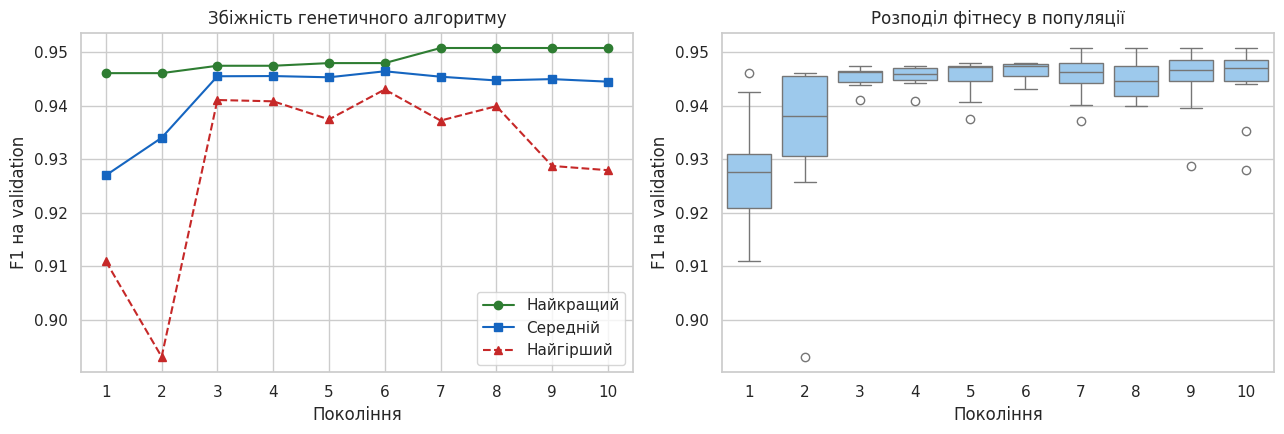

In [12]:
# Створюємо фігуру з двома графіками поруч
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
# Лівий графік: найкращий, середній і найгірший фітнес у кожному поколінні
axes[0].plot(ga_history["Покоління"], ga_history["Найкращий F1"], "o-", label="Найкращий", color="#2E7D32")
axes[0].plot(ga_history["Покоління"], ga_history["Середній F1"], "s-", label="Середній", color="#1565C0")
axes[0].plot(ga_history["Покоління"], ga_history["Найгірший F1"], "^--", label="Найгірший", color="#C62828")
# Підписи осей і заголовок
axes[0].set_xlabel("Покоління")
axes[0].set_ylabel("F1 на validation")
axes[0].set_title("Збіжність генетичного алгоритму")
# Позначки на осі X - номери поколінь
axes[0].set_xticks(ga_history["Покоління"])
# Легенда
axes[0].legend()

# Правий графік: розподіл фітнесу всередині кожного покоління (boxplot)
sns.boxplot(data=ga_population, x="generation", y="fitness", ax=axes[1], color="#90CAF9")
# Підписи осей і заголовок
axes[1].set_xlabel("Покоління")
axes[1].set_ylabel("F1 на validation")
axes[1].set_title("Розподіл фітнесу в популяції")
# Вирівнюємо відступи та відображаємо графіки
fig.tight_layout()
plt.show()

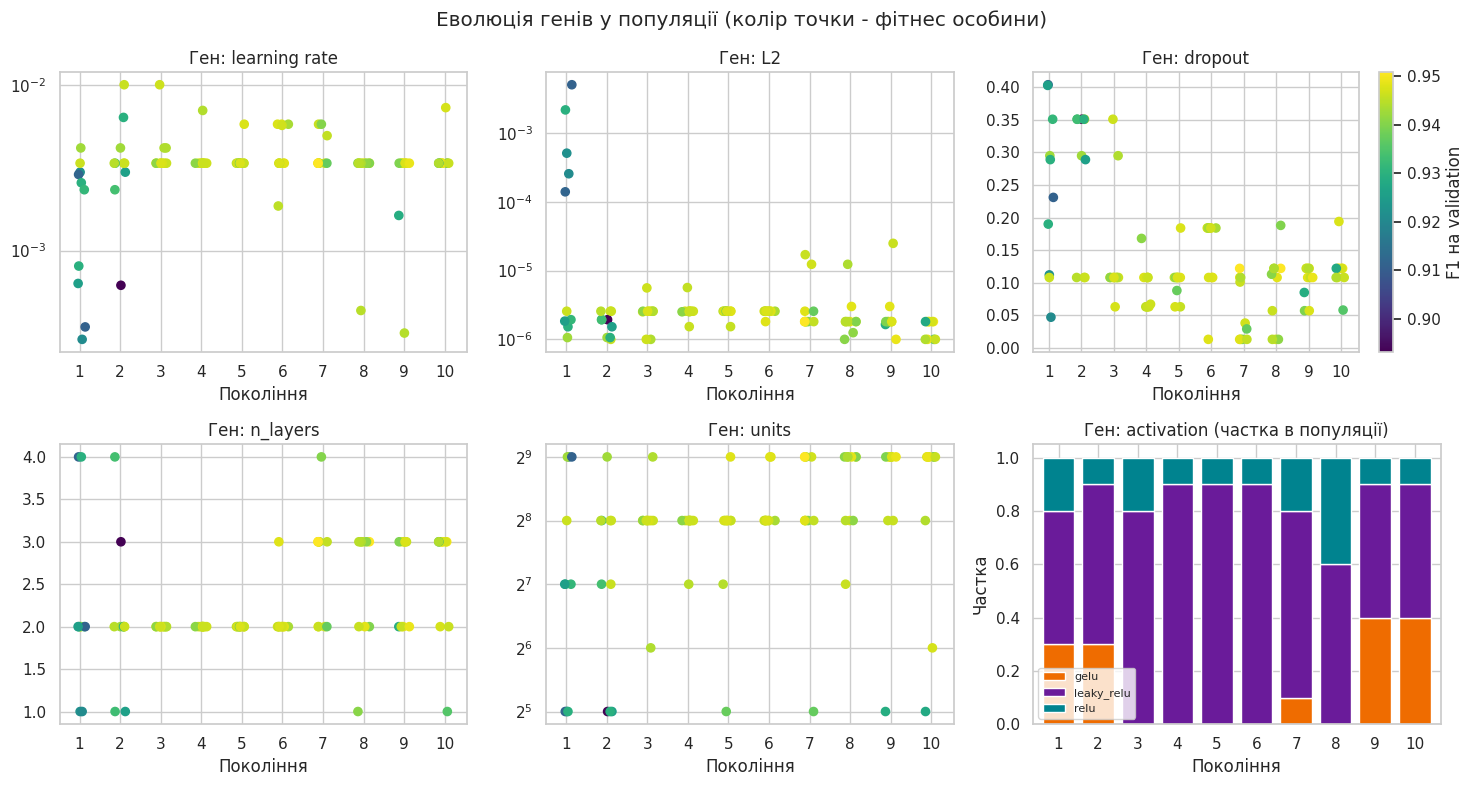

In [13]:
# Копія складу поколінь для побудови графіків
gp = ga_population.copy()
# Переводимо learning rate і L2 з логарифмічної шкали у звичайну
gp["learning rate"] = 10 ** gp["log_lr"]
gp["L2"] = 10 ** gp["log_l2"]
# Невеликий випадковий зсув по осі X, щоб точки однакових особин не зливались
jitter = np.random.RandomState(0).uniform(-0.15, 0.15, len(gp))

# Створюємо фігуру із сітки 2 x 3 графіків
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
# Для кожного числового гена будуємо діаграму розсіювання "покоління - значення гена"
for ax, gene, log_scale in [(axes[0, 0], "learning rate", True), (axes[0, 1], "L2", True),
                            (axes[0, 2], "dropout", False), (axes[1, 0], "n_layers", False),
                            (axes[1, 1], "units", False)]:
    # Колір точки показує фітнес особини
    sc = ax.scatter(gp["generation"] + jitter, gp[gene], c=gp["fitness"], cmap="viridis", s=35)
    # Для learning rate і L2 використовуємо логарифмічну шкалу
    if log_scale:
        ax.set_yscale("log")
    # Для кількості нейронів - логарифмічна шкала з основою 2 (32, 64, 128, ...)
    if gene == "units":
        ax.set_yscale("log", base=2)
    # Заголовок і підпис осі X
    ax.set_title(f"Ген: {gene}")
    ax.set_xlabel("Покоління")
    # Позначки на осі X - номери поколінь
    ax.set_xticks(range(1, N_GENERATIONS + 1))
# Шкала кольорів для фітнесу
fig.colorbar(sc, ax=axes[0, 2], label="F1 на validation")

# Частка кожної функції активації в поколінні (таблиця спряженості, нормована по рядках)
act_share = pd.crosstab(gp["generation"], gp["activation"], normalize="index")
# Накопичена стовпчикова діаграма часток активацій
act_share.plot(kind="bar", stacked=True, ax=axes[1, 2], color=["#EF6C00", "#6A1B9A", "#00838F"], width=0.8)
# Заголовок і підписи осей
axes[1, 2].set_title("Ген: activation (частка в популяції)")
axes[1, 2].set_xlabel("Покоління")
axes[1, 2].set_ylabel("Частка")
# Легенда меншим шрифтом
axes[1, 2].legend(fontsize=8, loc="lower left")
# Підписи поколінь горизонтально
axes[1, 2].tick_params(axis="x", rotation=0)
# Загальний заголовок фігури
fig.suptitle("Еволюція генів у популяції (колір точки - фітнес особини)")
# Вирівнюємо відступи та відображаємо графіки
fig.tight_layout()
plt.show()

## 10. Порівняння з випадковим пошуком

Щоб перевірити, чи дає еволюція перевагу, запускаємо випадковий пошук (random search) з **тим самим бюджетом** –
така сама кількість навчених мереж, та сама фітнес-функція.

In [14]:
# Бюджет випадкового пошуку = кількість мереж, навчених генетичним алгоритмом
budget = len(ga_evals)
# Окремий генератор випадкових чисел для випадкового пошуку
rs_rng = random.Random(SEED + 1)
# Власні кеш і журнал оцінок випадкового пошуку
rs_cache, rs_log = {}, []
# Фіксуємо час початку
rs_start = time.time()
# Оцінюємо випадкові особини, доки не вичерпаємо бюджет
while len(rs_log) < budget:
    fitness(random_individual(rs_rng), rs_cache, rs_log)
# Обчислюємо час роботи випадкового пошуку
rs_time = time.time() - rs_start
# Перетворюємо журнал оцінок у таблицю
rs_evals = pd.DataFrame(rs_log)
# Рядок таблиці з найкращим фітнесом
best_row = rs_evals.loc[rs_evals["fitness"].idxmax()]
# Відновлюємо найкращу особину у вигляді словника; .item() перетворює типи NumPy у звичайні Python-типи
rs_best = {g: (best_row[g].item() if hasattr(best_row[g], "item") else best_row[g]) for g in GENE_NAMES}

# Виводимо бюджет і час
print(f"Бюджет: {budget} навчених мереж, час: {rs_time / 60:.1f} хв")
# Порівнюємо найкращі знайдені конфігурації
print(f"Найкращий F1 випадкового пошуку: {rs_evals['fitness'].max():.4f} | {describe(rs_best)}")
print(f"Найкращий F1 генетичного алгоритму: {ga_evals['fitness'].max():.4f} | {describe(ga_best)}")
# Порівнюємо середню якість усіх оцінених особин
print(f"Середній F1 оцінених особин: GA = {ga_evals['fitness'].mean():.4f}, "
      f"random search = {rs_evals['fitness'].mean():.4f}")

Бюджет: 74 навчених мереж, час: 11.4 хв
Найкращий F1 випадкового пошуку: 0.9494 | шари [512, 256, 128], gelu, BN=так, dropout=0.25, lr=8.9e-03, L2=9.3e-06, batch=128
Найкращий F1 генетичного алгоритму: 0.9508 | шари [512, 256, 128], leaky_relu, BN=ні, dropout=0.12, lr=3.4e-03, L2=1.8e-06, batch=128
Середній F1 оцінених особин: GA = 0.9405, random search = 0.9128


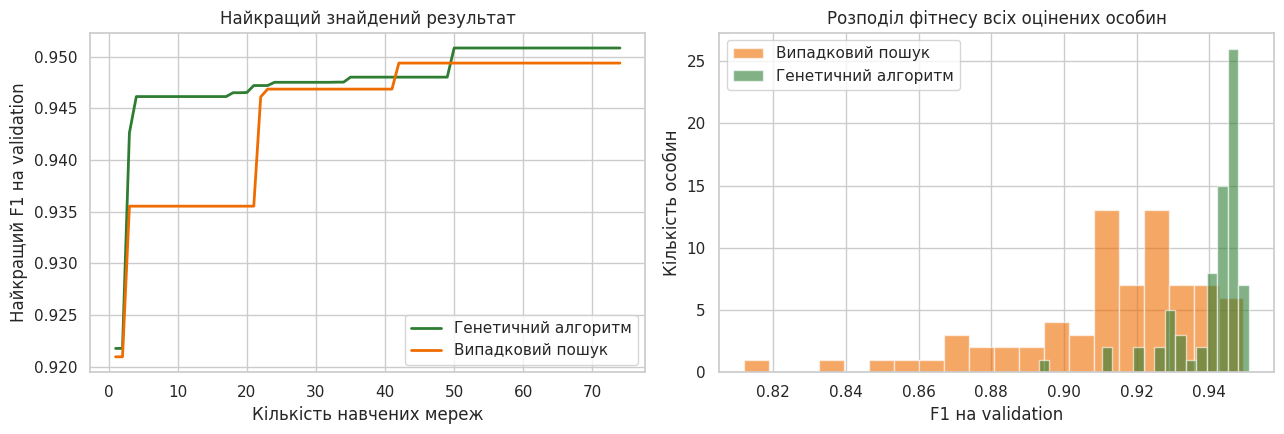

In [15]:
# Створюємо фігуру з двома графіками поруч
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
# Номери навчених мереж: 1, 2, ..., budget
x = np.arange(1, budget + 1)
# Лівий графік: найкращий знайдений F1 залежно від кількості навчених мереж (накопичений максимум)
axes[0].plot(x, ga_evals["fitness"].cummax(), label="Генетичний алгоритм", color="#2E7D32", lw=2)
axes[0].plot(x, rs_evals["fitness"].cummax(), label="Випадковий пошук", color="#EF6C00", lw=2)
# Підписи осей, заголовок і легенда
axes[0].set_xlabel("Кількість навчених мереж")
axes[0].set_ylabel("Найкращий F1 на validation")
axes[0].set_title("Найкращий знайдений результат")
axes[0].legend()

# Правий графік: гістограми фітнесу всіх оцінених особин обох методів
axes[1].hist(rs_evals["fitness"], bins=20, alpha=0.6, label="Випадковий пошук", color="#EF6C00")
axes[1].hist(ga_evals["fitness"], bins=20, alpha=0.6, label="Генетичний алгоритм", color="#2E7D32")
# Підписи осей, заголовок і легенда
axes[1].set_xlabel("F1 на validation")
axes[1].set_ylabel("Кількість особин")
axes[1].set_title("Розподіл фітнесу всіх оцінених особин")
axes[1].legend()
# Вирівнюємо відступи та відображаємо графіки
fig.tight_layout()
plt.show()

## 11. Фінальне навчання на повних даних і оцінка на тестовій вибірці

Три конфігурації навчаються на всій збалансованій train (до 20 епох, рання зупинка за val_loss з відновленням
найкращих ваг) і оцінюються на тестовій вибірці, яку жодна з них не бачила:
1. ручна конфігурація – ускладнена мережа з лабораторної роботи №1 (GELU);
2. найкраща особина випадкового пошуку;
3. найкраща особина генетичного алгоритму.

In [16]:
# Ручна конфігурація з лабораторної роботи №1: ускладнена мережа 256-128-64, GELU, BN, Dropout, L2
# (у лабі 1 dropout останнього шару був 0.2, тут для всіх шарів 0.3, бо ген dropout один на всю мережу)
manual = {"n_layers": 3, "units": 256, "activation": "gelu", "batch_norm": True,
          "batch_size": 256, "dropout": 0.3, "log_lr": -3.0, "log_l2": -4.0}

# Три конфігурації, які порівнюємо на тестовій вибірці
CONFIGS = {"Ручна (лаба 1)": manual, "Random search": rs_best, "Генетичний алгоритм": ga_best}
# Максимальна кількість епох фінального навчання
FINAL_EPOCHS = 20

# Словники для навчених моделей та історій навчання, список рядків таблиці результатів
final_models, final_histories, final_rows = {}, {}, []
# Навчаємо і оцінюємо кожну конфігурацію
for name, ind in CONFIGS.items():
    # Очищаємо стан Keras і фіксуємо зерно: однакові стартові умови
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)
    # Будуємо мережу за генами конфігурації
    model = build_model(ind)
    # Рання зупинка: якщо val_loss не покращується 4 епохи, навчання зупиняється,
    # а ваги відновлюються з найкращої епохи
    early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4,
                                                  restore_best_weights=True)
    # Фіксуємо час початку навчання
    start = time.time()
    # Навчаємо на ПОВНІЙ збалансованій train, якість після кожної епохи перевіряємо на validation
    hist = model.fit(X_train_bal, y_train_bal, validation_data=(X_val_sc, y_val),
                     epochs=FINAL_EPOCHS, batch_size=ind["batch_size"],
                     callbacks=[early_stop], verbose=0)
    # Час навчання в секундах
    seconds = time.time() - start
    # Ймовірності класу satisfied для тестової вибірки
    proba = model.predict(X_test_sc, batch_size=4096, verbose=0).ravel()
    # Класи за порогом 0.5
    pred = (proba >= 0.5).astype(int)
    # Зберігаємо модель та історію навчання
    final_models[name], final_histories[name] = model, hist.history
    # Обчислюємо метрики на тестовій вибірці і додаємо рядок у таблицю
    final_rows.append({"Модель": name,
                       "Accuracy": accuracy_score(y_test, pred),    # частка правильних прогнозів
                       "Precision": precision_score(y_test, pred),  # точність прогнозу satisfied
                       "Recall": recall_score(y_test, pred),        # повнота: частка знайдених satisfied
                       "F1": f1_score(y_test, pred),                # гармонійне середнє precision і recall
                       "ROC-AUC": roc_auc_score(y_test, proba),     # якість розділення класів за ймовірностями
                       "Епох": len(hist.history["loss"]),           # фактична кількість епох
                       "Параметрів": model.count_params(),          # кількість параметрів мережі
                       "Час, с": seconds,                           # час навчання
                       "_pred": pred})                              # прогнози (для матриць невідповідностей)
    # Виводимо опис конфігурації і короткий результат
    print(f"{name:<20} | {describe(ind)}")
    print(f"{'':<20} | епох: {len(hist.history['loss'])}, час: {seconds:.1f} с, "
          f"F1 (test) = {final_rows[-1]['F1']:.4f}")

# Зводимо результати в таблицю, назва моделі - індекс рядка
test_results = pd.DataFrame(final_rows).set_index("Модель")
# Виводимо таблицю без службової колонки з прогнозами
test_results.drop(columns="_pred").round(4)

Ручна (лаба 1)       | шари [256, 128, 64], gelu, BN=так, dropout=0.30, lr=1.0e-03, L2=1.0e-04, batch=256
                     | епох: 20, час: 81.1 с, F1 (test) = 0.9554
Random search        | шари [512, 256, 128], gelu, BN=так, dropout=0.25, lr=8.9e-03, L2=9.3e-06, batch=128
                     | епох: 6, час: 51.9 с, F1 (test) = 0.9493
Генетичний алгоритм  | шари [512, 256, 128], leaky_relu, BN=ні, dropout=0.12, lr=3.4e-03, L2=1.8e-06, batch=128
                     | епох: 13, час: 83.1 с, F1 (test) = 0.9519


,Accuracy,Precision,Recall,F1,ROC-AUC,Епох,Параметрів,"Час, с"
Модель,,,,,,,,
Ручна (лаба 1),0.9615,0.9604,0.9504,0.9554,0.9948,20,49409,81.1218
Random search,0.9566,0.9616,0.9374,0.9493,0.9932,6,180737,51.9272
Генетичний алгоритм,0.9584,0.9543,0.9495,0.9519,0.9945,13,177153,83.0508


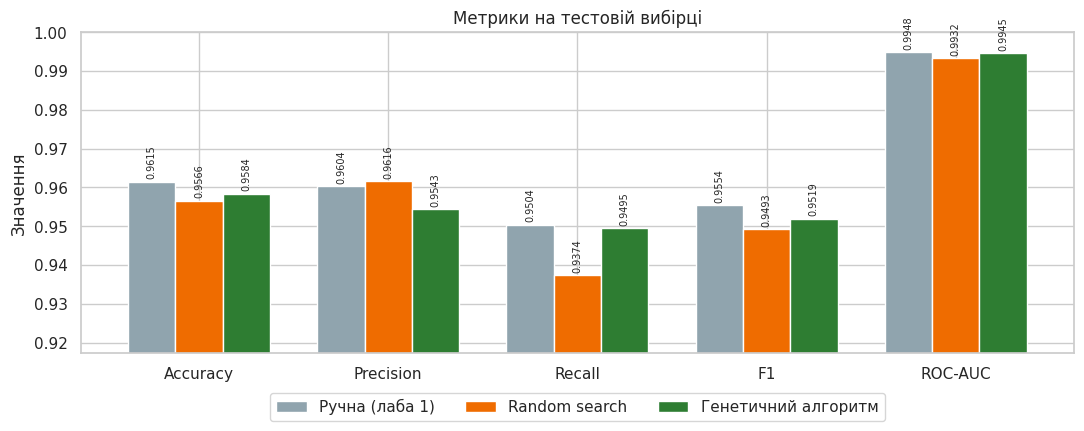

In [17]:
# Метрики, які відображаємо на графіку
metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
# Згрупована стовпчикова діаграма: групи - метрики, стовпці - моделі
ax = test_results[metrics].T.plot(kind="bar", figsize=(11, 4.5), width=0.75,
                                  color=["#90A4AE", "#EF6C00", "#2E7D32"])
# Нижня межа осі Y трохи нижча за мінімальну метрику, щоб різницю було видно
low = test_results[metrics].values.min()
ax.set_ylim(max(0, low - 0.02), 1.0)
# Заголовок і підпис осі Y
ax.set_title("Метрики на тестовій вибірці")
ax.set_ylabel("Значення")
# Назви метрик горизонтально
ax.tick_params(axis="x", rotation=0)
# Підписуємо значення над кожним стовпцем
for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", fontsize=7, rotation=90, padding=2)
# Легенда під графіком в один рядок
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=3)
# Вирівнюємо відступи та відображаємо графік
plt.tight_layout()
plt.show()

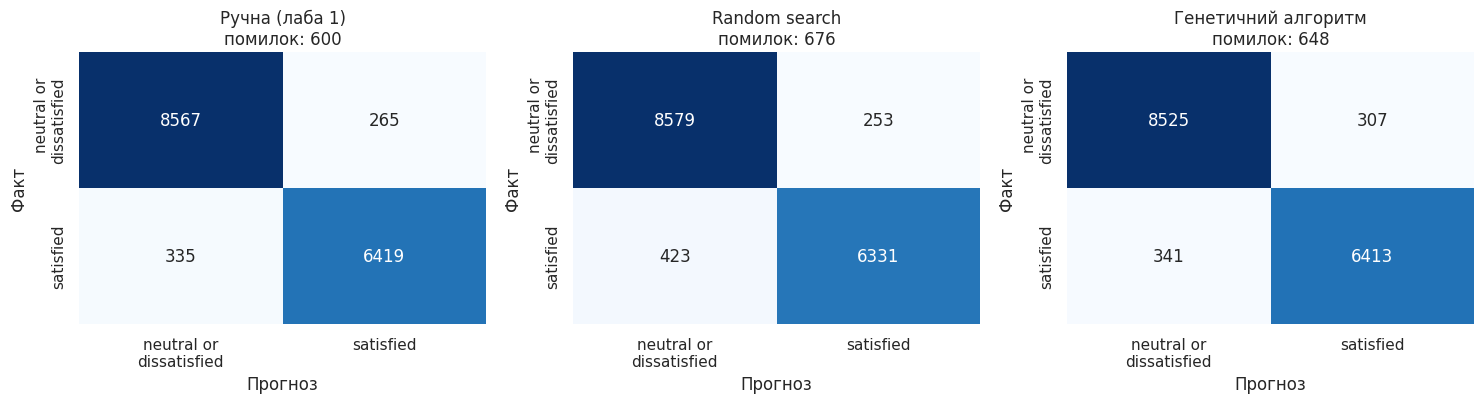

In [18]:
# Створюємо фігуру з трьома матрицями невідповідностей поруч
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
# Назви класів для підписів осей
labels = ["neutral or\ndissatisfied", "satisfied"]
# Для кожної моделі будуємо матрицю невідповідностей
for ax, (name, row) in zip(axes, test_results.iterrows()):
    # Матриця: рядки - фактичний клас, стовпці - прогноз
    cm = confusion_matrix(y_test, row["_pred"])
    # Теплова карта з кількістю записів у клітинках
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=labels, yticklabels=labels)
    # Заголовок: назва моделі та загальна кількість помилок (сума позадіагональних клітинок)
    ax.set_title(f"{name}\nпомилок: {cm[0, 1] + cm[1, 0]}")
    # Підписи осей
    ax.set_xlabel("Прогноз")
    ax.set_ylabel("Факт")
# Вирівнюємо відступи та відображаємо графіки
fig.tight_layout()
plt.show()

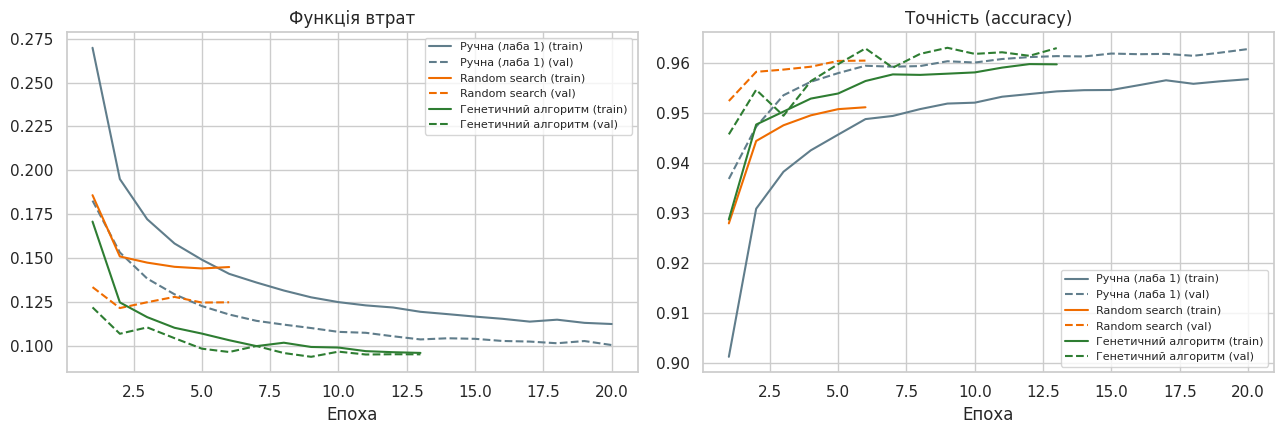

In [19]:
# Кольори моделей на графіках
colors = {"Ручна (лаба 1)": "#607D8B", "Random search": "#EF6C00", "Генетичний алгоритм": "#2E7D32"}
# Створюємо фігуру з двома графіками поруч
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
# Для кожної моделі малюємо криві навчання
for name, h in final_histories.items():
    # Номери епох
    ep = range(1, len(h["loss"]) + 1)
    # Функція втрат: суцільна лінія - train, пунктир - validation
    axes[0].plot(ep, h["loss"], "-", color=colors[name], label=f"{name} (train)")
    axes[0].plot(ep, h["val_loss"], "--", color=colors[name], label=f"{name} (val)")
    # Точність: суцільна лінія - train, пунктир - validation
    axes[1].plot(ep, h["accuracy"], "-", color=colors[name], label=f"{name} (train)")
    axes[1].plot(ep, h["val_accuracy"], "--", color=colors[name], label=f"{name} (val)")
# Заголовки графіків
axes[0].set_title("Функція втрат")
axes[1].set_title("Точність (accuracy)")
# Підпис осі X і легенда для обох графіків
for ax in axes:
    ax.set_xlabel("Епоха")
    ax.legend(fontsize=8)
# Вирівнюємо відступи та відображаємо графіки
fig.tight_layout()
plt.show()

In [20]:
# Назва моделі з найбільшим F1 на тестовій вибірці
best_name = test_results["F1"].idxmax()
# Підсумок роботи генетичного алгоритму
print(f"Час еволюції: {ga_time / 60:.1f} хв, навчено мереж: {len(ga_evals)}")
print(f"Найкраща конфігурація GA: {describe(ga_best)}")
print(f"F1 на validation під час еволюції: {ga_evals['fitness'].max():.4f}")
print()
# Ключові метрики всіх трьох моделей на тестовій вибірці
for name, row in test_results.iterrows():
    print(f"{name:<20}: F1 (test) = {row['F1']:.4f}, accuracy = {row['Accuracy']:.4f}, "
          f"ROC-AUC = {row['ROC-AUC']:.4f}, параметрів = {row['Параметрів']}")
# Найкраща модель на тестовій вибірці
print(f"\nНайкраща модель на тестовій вибірці: {best_name}")

Час еволюції: 13.9 хв, навчено мереж: 74
Найкраща конфігурація GA: шари [512, 256, 128], leaky_relu, BN=ні, dropout=0.12, lr=3.4e-03, L2=1.8e-06, batch=128
F1 на validation під час еволюції: 0.9508

Ручна (лаба 1)      : F1 (test) = 0.9554, accuracy = 0.9615, ROC-AUC = 0.9948, параметрів = 49409
Random search       : F1 (test) = 0.9493, accuracy = 0.9566, ROC-AUC = 0.9932, параметрів = 180737
Генетичний алгоритм : F1 (test) = 0.9519, accuracy = 0.9584, ROC-AUC = 0.9945, параметрів = 177153

Найкраща модель на тестовій вибірці: Ручна (лаба 1)
